# 03 - Phân tích lỗi

**Giai đoạn trong pipeline:** ... -> Đánh giá trên tập test cuối cùng -> **Ma trận nhầm lẫn ->
Phân tích lỗi phân loại sai** -> So sánh mô hình -> Kết luận

Mô hình cuối cùng được chọn: **`resnet18/run_003`** (ResNet18 fine-tune `layer4` và `fc`)
- được chọn trong `02_training_and_comparison.ipynb` dựa trên validation accuracy 0.9320,
cao nhất trong các lần chạy chính thức. Notebook này nạp các artifact đánh giá trên tập test đã lưu của lần
chạy đó (được tạo ra bởi `scripts/evaluate.py`) - nó không chạy lại suy luận (inference) từ
đầu.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torchvision import datasets

from src.dataset import CLASS_NAMES, DATA_DIR
from src.evaluation import find_top_confusion_pairs
from src.visualization import plot_confusion_matrix, plot_misclassified_grid

FINAL_RUN_DIR = PROJECT_ROOT / "runs" / "resnet18" / "run_003"

## Số liệu kiểm tra cuối cùng


In [2]:
with open(FINAL_RUN_DIR / "metrics" / "final_metrics.json", "r") as f:
    final_metrics = json.load(f)

final_metrics

{'run_id': 'run_003',
 'model': 'resnet18',
 'best_epoch': 4,
 'best_val_loss': 0.19287407636642456,
 'best_val_accuracy': 0.932,
 'final_train_accuracy': 0.9715185185185186,
 'final_val_accuracy': 0.9275,
 'test_accuracy': 0.9287}

## Ma trận nhầm lẫn (Confusion Matrix)

Được nạp từ `metrics/confusion_matrix.csv` (số lượng thực tế, hàng = nhãn thật, cột =
nhãn dự đoán), do `scripts/evaluate.py` lưu lại.


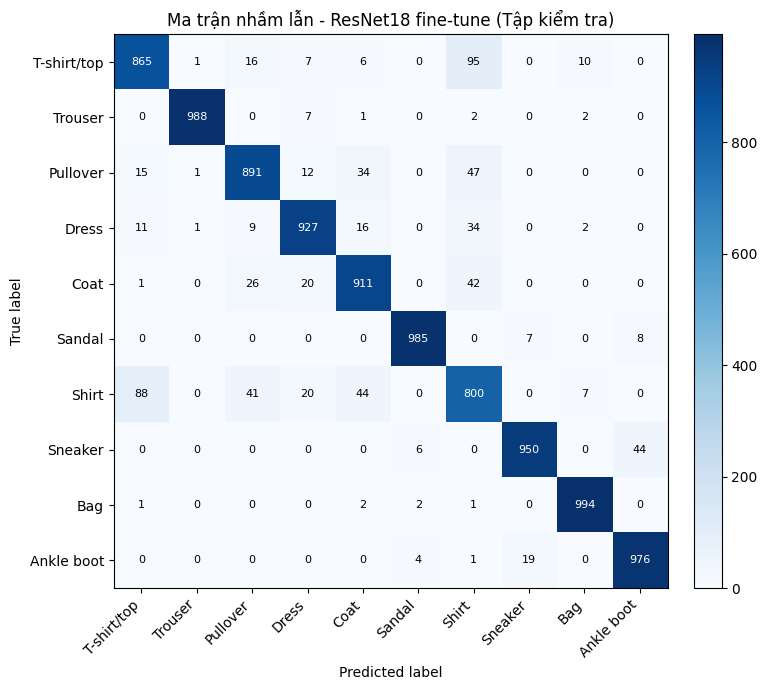

In [3]:
conf_matrix_df = pd.read_csv(FINAL_RUN_DIR / "metrics" / "confusion_matrix.csv", index_col=0)
conf_matrix = conf_matrix_df.values

fig = plot_confusion_matrix(conf_matrix, CLASS_NAMES, title="Ma trận nhầm lẫn - ResNet18 fine-tune (Tập kiểm tra)")
plt.show()


## Precision / Recall / F1 theo từng lớp


In [4]:
per_class_df = pd.read_csv(FINAL_RUN_DIR / "metrics" / "per_class_metrics.csv")
per_class_df.sort_values("f1_score")

,class,precision,recall,f1_score,support
6,Shirt,0.782779,0.800,0.791296,1000
0,T-shirt/top,0.881753,0.865,0.873296,1000
2,Pullover,0.906409,0.891,0.898638,1000
4,Coat,0.898422,0.911,0.904667,1000
3,Dress,0.933535,0.927,0.930256,1000
7,Sneaker,0.973361,0.950,0.961538,1000
9,Ankle boot,0.949416,0.976,0.962525,1000
5,Sandal,0.987964,0.985,0.986480,1000
8,Bag,0.979310,0.994,0.986600,1000
1,Trouser,0.996973,0.988,0.992466,1000


## Các cặp nhầm lẫn lớn nhất

Được xác định trực tiếp từ ma trận nhầm lẫn thực tế (không có giả định nào về việc lớp nào
bị nhầm lẫn được viết cứng trong code).


In [5]:
top_pairs_df = find_top_confusion_pairs(conf_matrix, CLASS_NAMES, top_k=8)
top_pairs_df

,true_label,predicted_label,count
0,T-shirt/top,Shirt,95
1,Shirt,T-shirt/top,88
2,Pullover,Shirt,47
3,Sneaker,Ankle boot,44
4,Shirt,Coat,44
5,Coat,Shirt,42
6,Shirt,Pullover,41
7,Pullover,Coat,34


## Các lỗi tiêu biểu: nhãn thật so với dự đoán, kèm độ tin cậy

`metrics/misclassified.csv` lưu `sample_index` (vị trí của mẫu trong tập test chính thức,
vì `test_loader` dùng `shuffle=False`), `true_label`, `predicted_label`, và `confidence`.
Chúng ta nạp lại các ảnh test gốc (chưa qua biến đổi) theo index để trực quan hóa chúng.


Tổng số mẫu test bị phân loại sai: 713 trên tổng số 10000


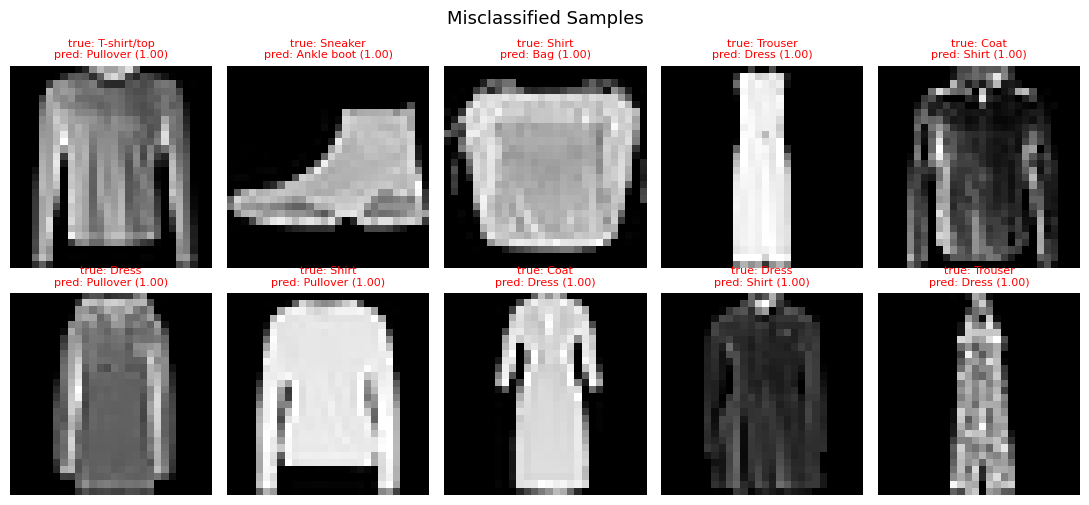

In [6]:
misclassified_df = pd.read_csv(FINAL_RUN_DIR / "metrics" / "misclassified.csv")
print(f"Tổng số mẫu test bị phân loại sai: {len(misclassified_df)} trên tổng số 10000")

raw_test = datasets.FashionMNIST(root=str(DATA_DIR), train=False, download=True)

# Sắp xếp giảm dần theo độ tin cậy: những lỗi mà mô hình "tự tin nhưng sai" thường là
# những trường hợp thú vị nhất để xem xét.
top_confident_errors = misclassified_df.sort_values("confidence", ascending=False).head(10)

images = np.stack([np.array(raw_test[i][0]) for i in top_confident_errors["sample_index"]])[:, None, :, :]
true_labels = top_confident_errors["true_label"].to_numpy()
predicted_labels = top_confident_errors["predicted_label"].to_numpy()
confidences = top_confident_errors["confidence"].to_numpy()

fig = plot_misclassified_grid(images, true_labels, predicted_labels, confidences, CLASS_NAMES, n=10)
plt.show()


## Xem xét cặp nhầm lẫn lớn nhất

Ô lệnh phía trên (`top_pairs_df`) đã xác định các cặp nhầm lẫn lớn nhất thực tế cho mô hình
này. Bên dưới, chúng ta lấy ra các mẫu bị phân loại sai thực tế cho cặp lớn nhất và trực
quan hóa chúng, để kết nối con số nhầm lẫn với hình ảnh thực tế.


Cặp nhầm lẫn lớn nhất: nhãn thật='T-shirt/top' dự đoán='Shirt' (số lượng=95)


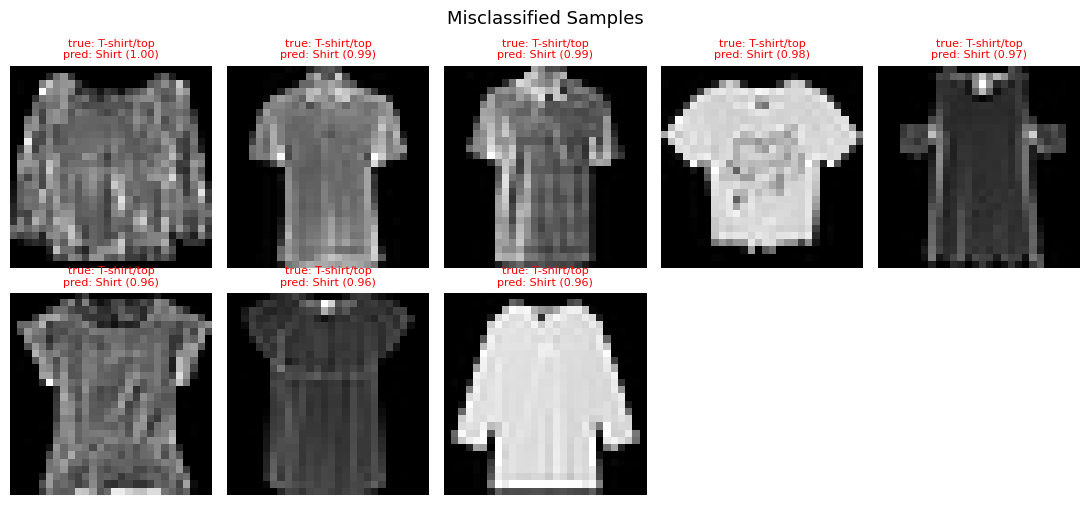

In [7]:
class_to_idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}
top_pair = top_pairs_df.iloc[0]
true_idx = class_to_idx[top_pair["true_label"]]
pred_idx = class_to_idx[top_pair["predicted_label"]]

print(f"Cặp nhầm lẫn lớn nhất: nhãn thật='{top_pair['true_label']}' dự đoán='{top_pair['predicted_label']}' "
      f"(số lượng={top_pair['count']})")

pair_mask = (misclassified_df["true_label"] == true_idx) & (misclassified_df["predicted_label"] == pred_idx)
pair_examples = misclassified_df[pair_mask].sort_values("confidence", ascending=False).head(8)

images = np.stack([np.array(raw_test[i][0]) for i in pair_examples["sample_index"]])[:, None, :, :]
true_labels = pair_examples["true_label"].to_numpy()
predicted_labels = pair_examples["predicted_label"].to_numpy()
confidences = pair_examples["confidence"].to_numpy()

fig = plot_misclassified_grid(images, true_labels, predicted_labels, confidences, CLASS_NAMES, n=len(pair_examples))
plt.show()


## Thảo luận: các nguyên nhân có thể gây nhầm lẫn

ResNet18 fine-tune dự đoán đúng 9.287 trên 10.000 ảnh test và phân loại sai 713 ảnh.
Các nhầm lẫn chủ yếu xảy ra giữa những lớp trang phục phần thân trên: **Shirt**,
**T-shirt/top**, **Pullover** và **Coat**. Điều này phù hợp với độ tương đồng hình ảnh:

- Cả bốn lớp đều có silhouette gần giống nhau (thân + tay áo ngắn/dài) ở độ phân giải
  28x28 ảnh xám, nơi các chi tiết nhỏ như cổ áo, cúc áo, hay chất liệu vải gần như không
  nhìn thấy được.
- Cặp lớn nhất là **T-shirt/top -> Shirt** với 95 ảnh; chiều ngược lại
  **Shirt -> T-shirt/top** có 88 ảnh. Khác biệt về cổ áo và tay áo khá tinh tế.
- **Shirt** là lớp khó nhất, có recall 80,00% và F1-score 79,13%. Shirt còn bị nhầm với
  Coat (44 ảnh) và Pullover (41 ảnh).
- **Sneaker -> Ankle boot** có 44 ảnh, phản ánh sự giống nhau ở phần đế và hình dáng giày.
- Trouser, Sandal và Bag có F1-score trên 98%, do silhouette khác biệt rõ ràng.

Dữ liệu đã được resize lên 224x224 để tương thích với ResNet18, nhưng nguồn ảnh gốc vẫn
chỉ có 28x28 nên không tạo thêm chi tiết mới. Các cải thiện tiếp theo nên tập trung vào
augmentation phù hợp, regularization và chiến lược unfreeze theo giai đoạn thay vì chỉ
tăng số epoch, vì lịch sử train đã cho thấy overfitting nhẹ.


## So sánh hiệu quả của fine-tuning

Bảng dưới đọc trực tiếp `final_metrics.json` của ba thí nghiệm Practice 2 để định lượng
mức cải thiện của mô hình được chọn.


In [8]:
comparison_runs = {
    "MobileNetV2 pretrained": PROJECT_ROOT / "runs" / "mobilenet_v2" / "run_002",
    "ResNet18 pretrained": PROJECT_ROOT / "runs" / "resnet18" / "run_001",
    "ResNet18 fine-tune": PROJECT_ROOT / "runs" / "resnet18" / "run_003",
}

comparison_records = []
for label, run_dir in comparison_runs.items():
    with open(run_dir / "metrics" / "final_metrics.json", "r", encoding="utf-8") as f:
        metrics = json.load(f)
    comparison_records.append({
        "Thí nghiệm": label,
        "Best epoch": metrics["best_epoch"],
        "Best validation accuracy": metrics["best_val_accuracy"],
        "Test accuracy": metrics["test_accuracy"],
    })

comparison_df = pd.DataFrame(comparison_records)
comparison_df.style.format({
    "Best validation accuracy": "{:.2%}",
    "Test accuracy": "{:.2%}",
})


,Thí nghiệm,Best epoch,Best validation accuracy,Test accuracy
0,MobileNetV2 pretrained,4,85.28%,85.12%
1,ResNet18 pretrained,5,86.38%,86.44%
2,ResNet18 fine-tune,4,93.20%,92.87%


## Kết luận cuối cùng

ResNet18 fine-tune đạt **92.87% test accuracy**, tăng **6,43 điểm phần trăm** so với
ResNet18 chỉ train classifier và tăng **7,75 điểm phần trăm** so với MobileNetV2 frozen.
Kết quả chứng minh các đặc trưng pretrained có ích, nhưng việc fine-tune khối cuối giúp
mô hình thích nghi tốt hơn đáng kể với FashionMNIST. Sai số còn lại tập trung ở các lớp
áo có hình dáng gần nhau, đặc biệt là Shirt và T-shirt/top.
